# Raw Routerset Audit

This notebook audits the rebuilt raw routerset snapshot under `routerset/multilabel_dataset`.

It does three things:

- runs a per-file integrity audit against the current raw manifest
- renders summary plots and dataset-level stats
- shows representative train and validation samples for each dataset with RGB and false-RGB views

The goal is to inspect the current routerset artifact directly, not one of the older materialized exports.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython import get_ipython
from IPython.display import Image, Markdown, display
from matplotlib_inline.backend_inline import set_matplotlib_formats

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists() and (PROJECT_ROOT.parent / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from hydranet.routerset_raw_audit import (
    RGB_CHANNELS,
    FALSE_RGB_CHANNELS,
    audit_raw_routerset_dataset,
    display_view,
    normalize_display,
)

ROUTERSET_DIR = PROJECT_ROOT / 'routerset'
DATASET_ROOT = ROUTERSET_DIR
AUDIT_DIR = DATASET_ROOT / 'audit_raw'

ip = get_ipython()
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')
set_matplotlib_formats('png')
plt.rcParams['figure.figsize'] = (18, 5)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.max_open_warning'] = 0

if (AUDIT_DIR / 'summary.json').exists() and (AUDIT_DIR / 'sample_rows.json').exists():
    summary = json.loads((AUDIT_DIR / 'summary.json').read_text(encoding='utf-8'))
else:
    summary = audit_raw_routerset_dataset(DATASET_ROOT, output_dir=AUDIT_DIR)
sample_rows = json.loads((AUDIT_DIR / 'sample_rows.json').read_text(encoding='utf-8'))['rows']

print('dataset_root:', DATASET_ROOT)
print('audit_dir:', AUDIT_DIR)
print('row_count:', summary['row_count'])
print('status_counts:', summary['status_counts'])


dataset_root: /shared/home/rdelprete/PythonProjects/hydranet-phisat2/routerset
audit_dir: /shared/home/rdelprete/PythonProjects/hydranet-phisat2/routerset/audit_raw
row_count: 10151
status_counts: {'ok': 10151}


In [2]:
display(Markdown('## Summary'))
print(json.dumps(summary, indent=2))


## Summary

{
  "dataset_root": "routerset",
  "file_audit_path": "routerset/audit_raw/file_audit.jsonl",
  "issue_counts": {},
  "manifest_path": "routerset/manifest.jsonl",
  "note_counts": {
    "large_source_scene": 2,
    "raw_uint16_reflectance": 4,
    "sampled_large_array_stats": 12
  },
  "per_dataset": {
    "anomaly_detection": {
      "row_count": 36,
      "sample_dtype_counts": {
        "float32": 2
      },
      "sample_layout_counts": {
        "chw": 2
      },
      "sample_shape_counts": {
        "8x4096x4096": 2
      },
      "sample_zero_fraction": {
        "max": 0.0,
        "mean": 0.0,
        "median": 0.0,
        "min": 0.0
      },
      "split_counts": {
        "train": 25,
        "validation": 11
      },
      "status_counts": {
        "ok": 36
      }
    },
    "burned_area": {
      "row_count": 1299,
      "sample_dtype_counts": {
        "float32": 2
      },
      "sample_layout_counts": {
        "chw": 2
      },
      "sample_shape_counts": {
      

## Audit plots

dataset_split_counts.png


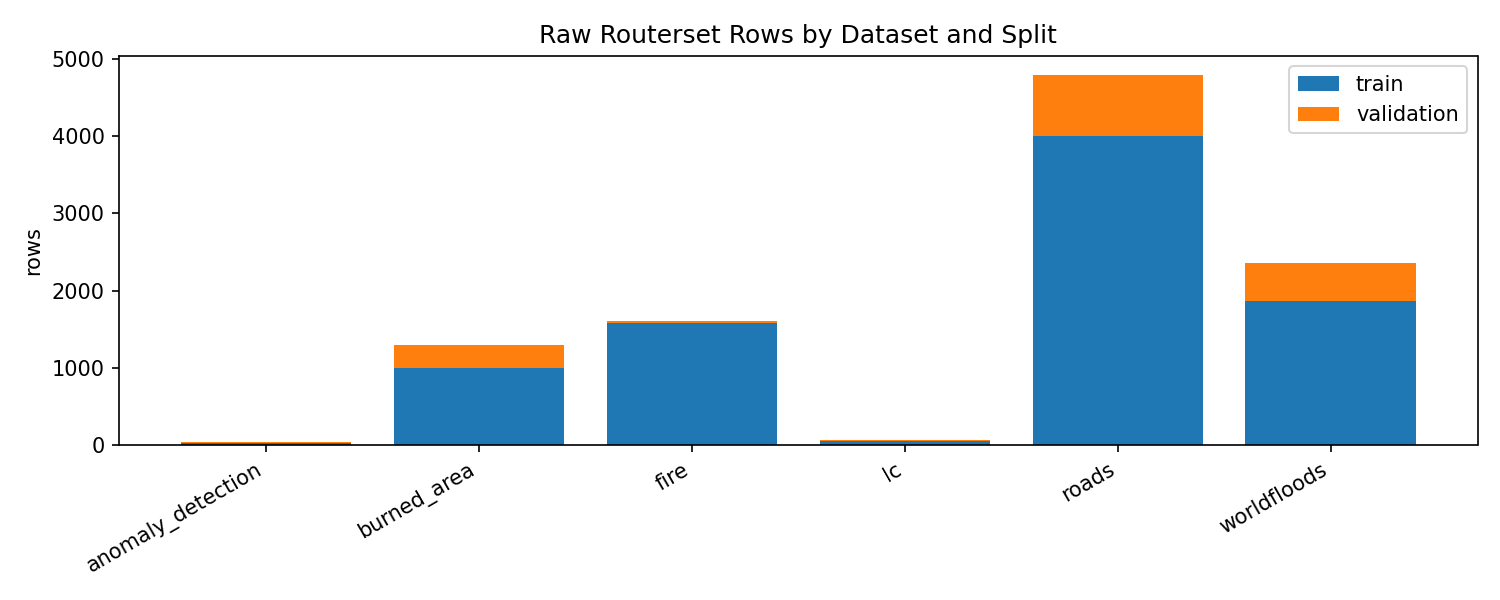

status_counts.png


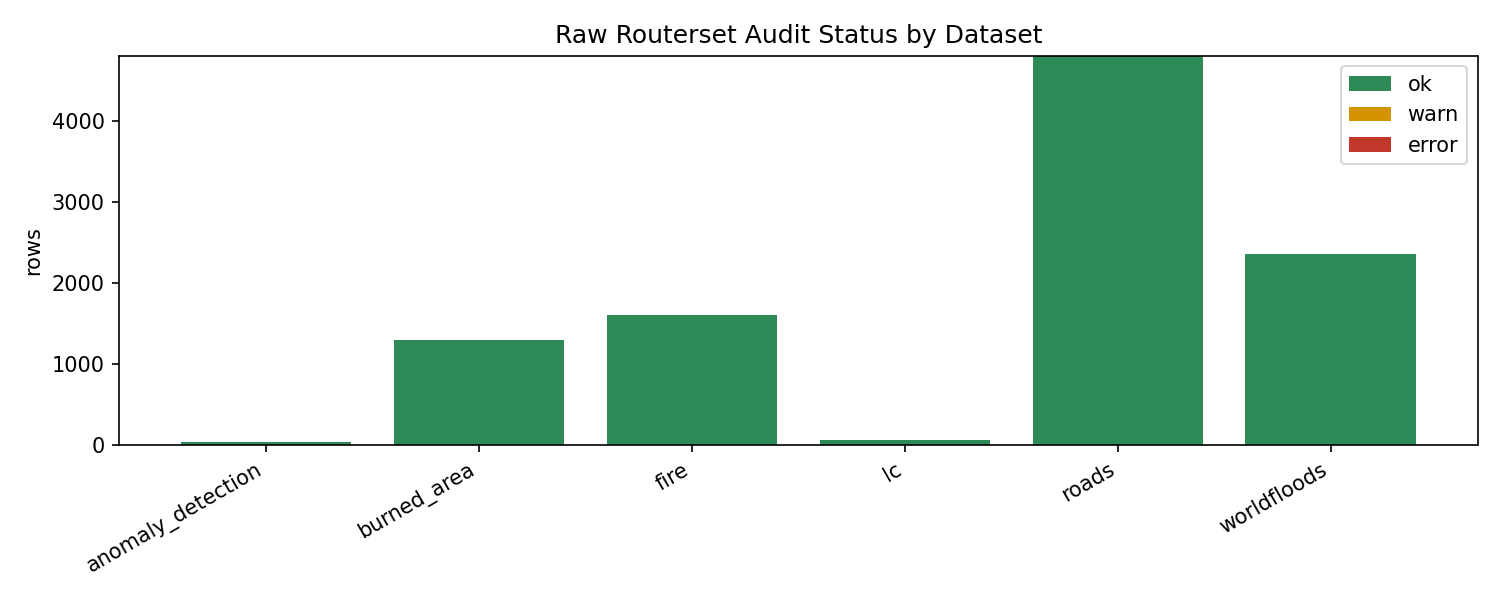

zero_fraction_boxplot.png


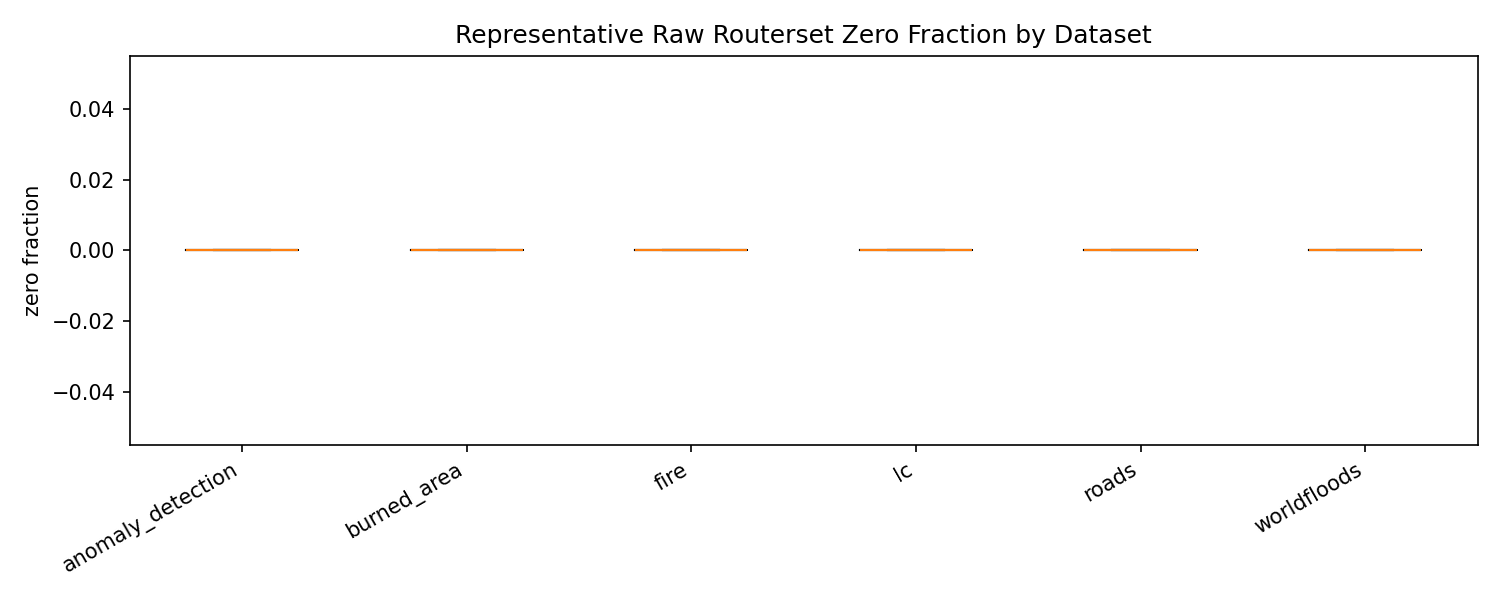

In [3]:
display(Markdown('## Audit plots'))
for name in ['dataset_split_counts.png', 'status_counts.png', 'zero_fraction_boxplot.png']:
    path = AUDIT_DIR / name
    print(path.name)
    display(Image(filename=str(path)))


## Sample gallery

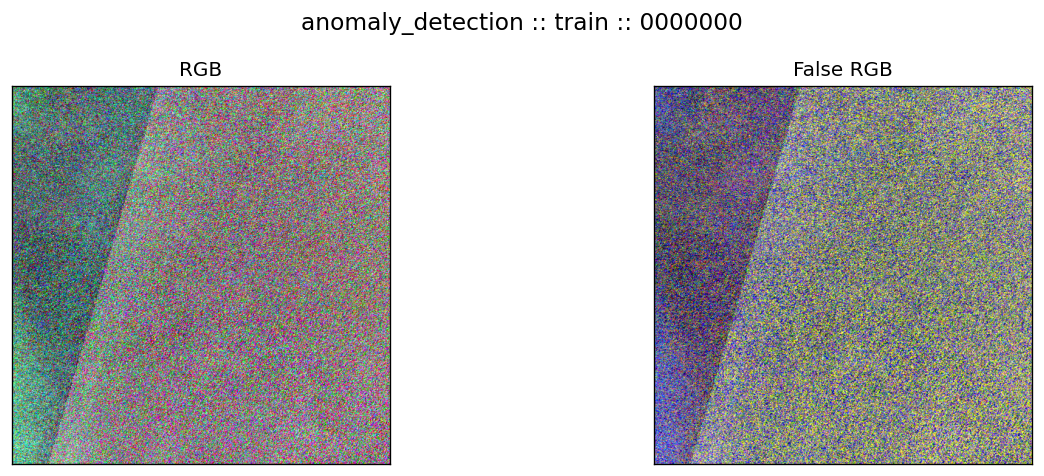

{
  "dataset": "anomaly_detection",
  "split": "train",
  "sample_id": "0000000",
  "image_path": "routerset/images/anomaly_detection/train/0000000_0_0_full_full.npy",
  "shape": [
    8,
    4096,
    4096
  ],
  "dtype": "float32",
  "layout": "chw",
  "min": 0.04537959769368172,
  "max": 0.12555456161499023,
  "mean": 0.07591770589351654,
  "zero_fraction": 0.0,
  "stats_sampled": true,
  "label_names": [
    "water"
  ],
  "status": "ok",
  "issue_codes": [],
  "note_codes": [
    "sampled_large_array_stats",
    "large_source_scene"
  ]
}


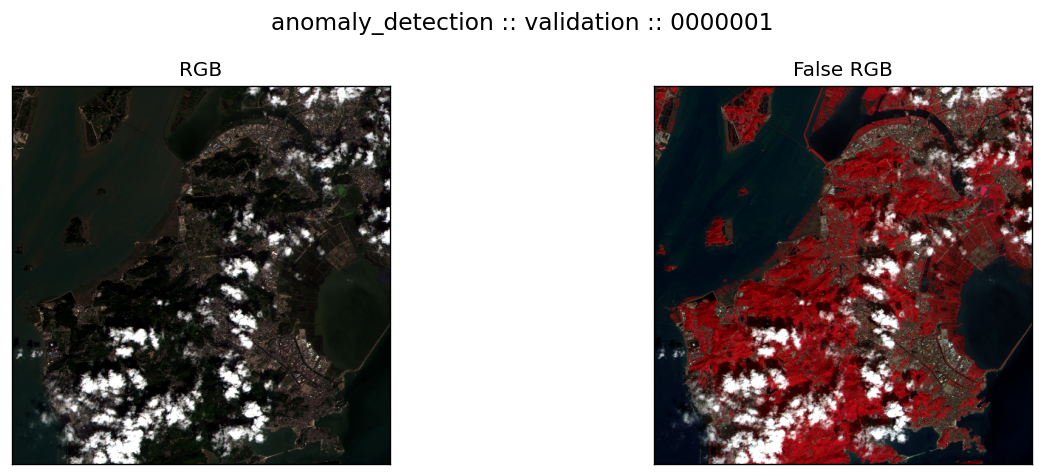

{
  "dataset": "anomaly_detection",
  "split": "validation",
  "sample_id": "0000001",
  "image_path": "routerset/images/anomaly_detection/validation/0000001_0_0_full_full.npy",
  "shape": [
    8,
    4096,
    4096
  ],
  "dtype": "float32",
  "layout": "chw",
  "min": 0.01733107678592205,
  "max": 0.36135321855545044,
  "mean": 0.08037959039211273,
  "zero_fraction": 0.0,
  "stats_sampled": true,
  "label_names": [
    "cloud",
    "land",
    "marine_algae",
    "turbid_water"
  ],
  "status": "ok",
  "issue_codes": [],
  "note_codes": [
    "sampled_large_array_stats",
    "large_source_scene"
  ]
}


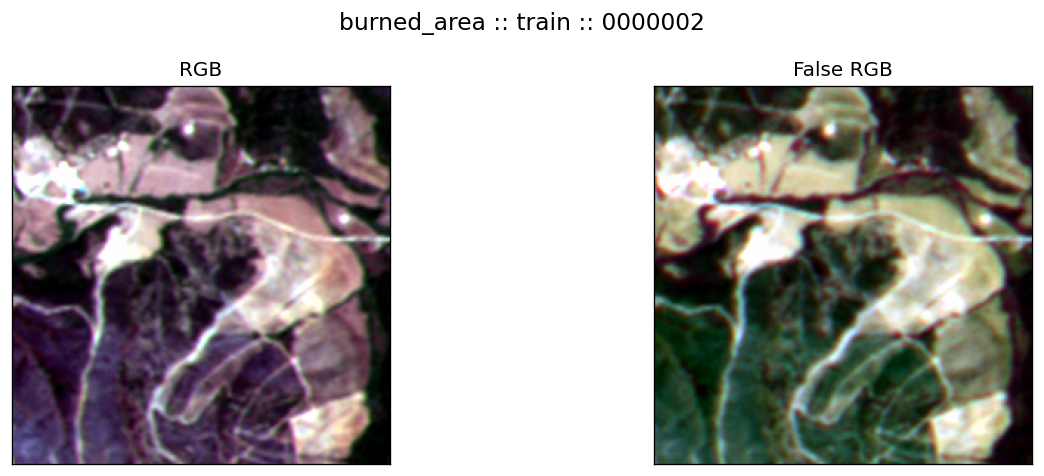

{
  "dataset": "burned_area",
  "split": "train",
  "sample_id": "0000002",
  "image_path": "routerset/images/burned_area/train/0000002_0_0_256_256.npy",
  "shape": [
    7,
    256,
    256
  ],
  "dtype": "float32",
  "layout": "chw",
  "min": 0.27564412355422974,
  "max": 0.9154667854309082,
  "mean": 0.5195792317390442,
  "zero_fraction": 0.0,
  "stats_sampled": true,
  "label_names": [
    "burned_area"
  ],
  "status": "ok",
  "issue_codes": [],
  "note_codes": [
    "sampled_large_array_stats"
  ]
}


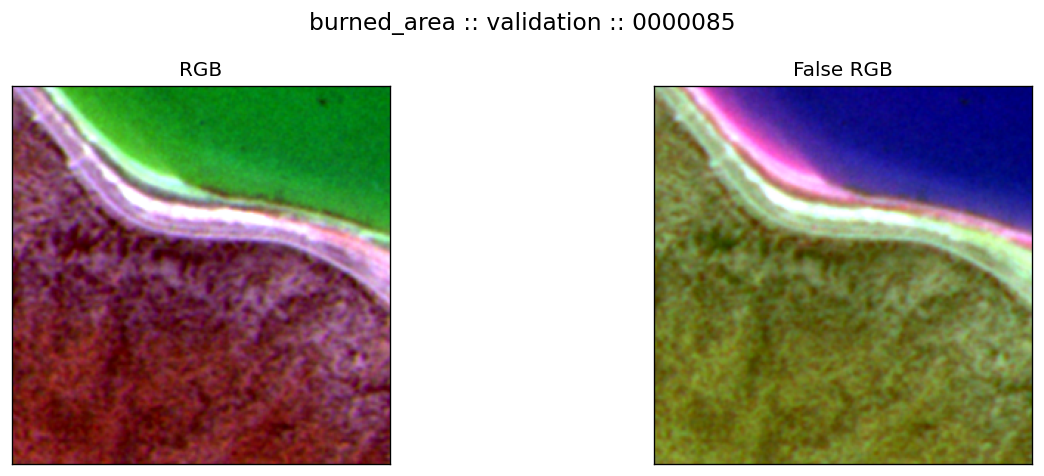

{
  "dataset": "burned_area",
  "split": "validation",
  "sample_id": "0000085",
  "image_path": "routerset/images/burned_area/validation/0000085_0_0_256_256.npy",
  "shape": [
    7,
    256,
    256
  ],
  "dtype": "float32",
  "layout": "chw",
  "min": 0.20250312983989716,
  "max": 0.8377116918563843,
  "mean": 0.4195631146430969,
  "zero_fraction": 0.0,
  "stats_sampled": true,
  "label_names": [
    "water"
  ],
  "status": "ok",
  "issue_codes": [],
  "note_codes": [
    "sampled_large_array_stats"
  ]
}


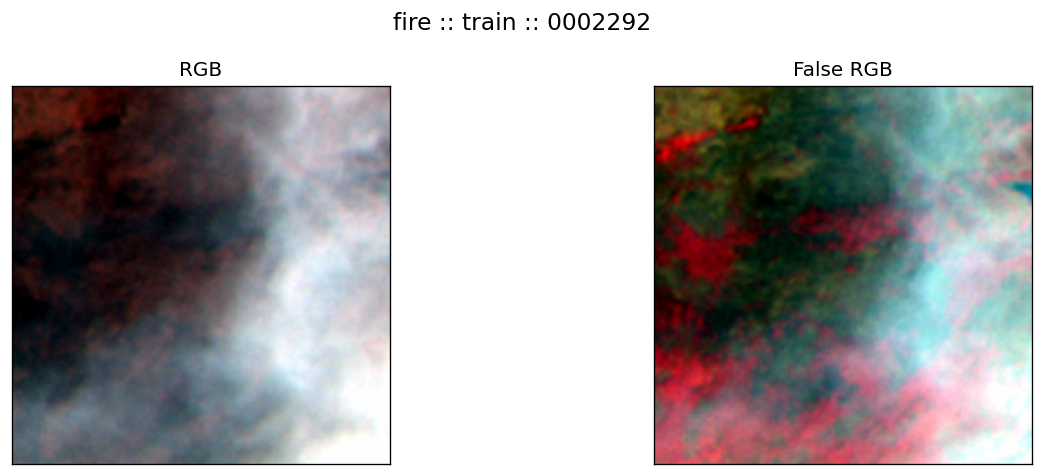

{
  "dataset": "fire",
  "split": "train",
  "sample_id": "0002292",
  "image_path": "routerset/images/fire/train/0002292_0_0_full_full.npy",
  "shape": [
    8,
    256,
    256
  ],
  "dtype": "float32",
  "layout": "chw",
  "min": 0.0967986136674881,
  "max": 0.29761406779289246,
  "mean": 0.17665749788284302,
  "zero_fraction": 0.0,
  "stats_sampled": true,
  "label_names": [
    "active_fire"
  ],
  "status": "ok",
  "issue_codes": [],
  "note_codes": [
    "sampled_large_array_stats"
  ]
}


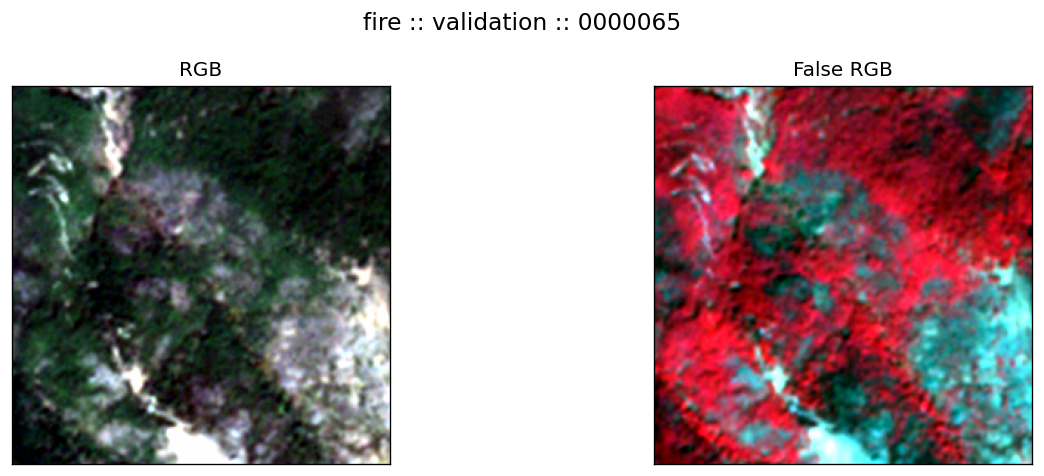

{
  "dataset": "fire",
  "split": "validation",
  "sample_id": "0000065",
  "image_path": "routerset/images/fire/validation/0000065_0_0_full_full.npy",
  "shape": [
    8,
    256,
    256
  ],
  "dtype": "float32",
  "layout": "chw",
  "min": 0.035020895302295685,
  "max": 0.3223167657852173,
  "mean": 0.1303606629371643,
  "zero_fraction": 0.0,
  "stats_sampled": true,
  "label_names": [],
  "status": "ok",
  "issue_codes": [],
  "note_codes": [
    "sampled_large_array_stats"
  ]
}


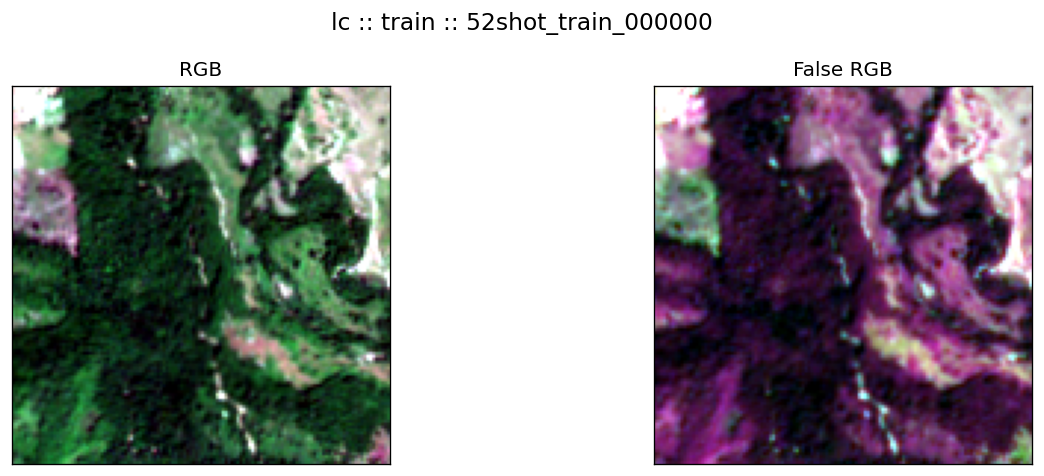

{
  "dataset": "lc",
  "split": "train",
  "sample_id": "52shot_train_000000",
  "image_path": "routerset/images/lc/train/52shot_train_000000_0_0_128_128.npy",
  "shape": [
    128,
    128,
    10
  ],
  "dtype": "uint16",
  "layout": "hwc",
  "min": 172.0,
  "max": 1361.0,
  "mean": 297.897216796875,
  "zero_fraction": 0.0,
  "stats_sampled": true,
  "label_names": [
    "grassland",
    "tree_cover"
  ],
  "status": "ok",
  "issue_codes": [],
  "note_codes": [
    "sampled_large_array_stats",
    "raw_uint16_reflectance"
  ]
}


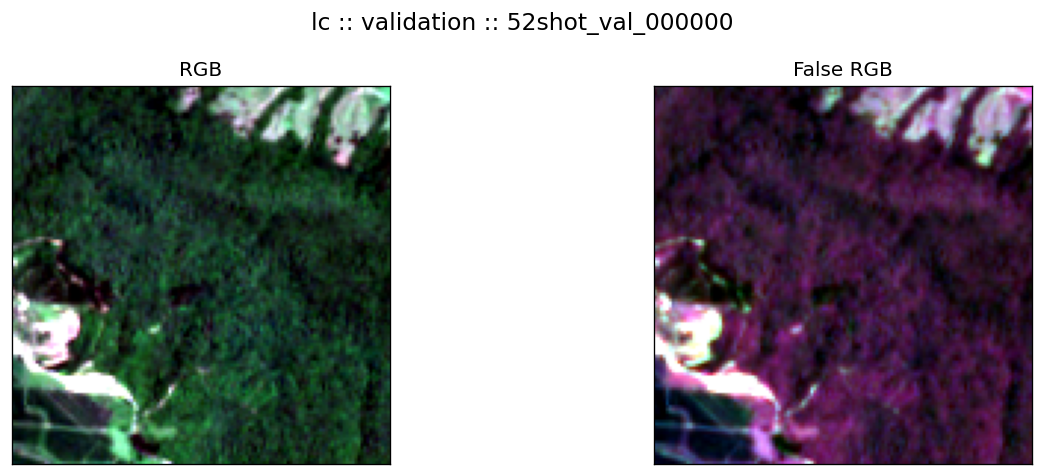

{
  "dataset": "lc",
  "split": "validation",
  "sample_id": "52shot_val_000000",
  "image_path": "routerset/images/lc/validation/52shot_val_000000_0_0_128_128.npy",
  "shape": [
    128,
    128,
    10
  ],
  "dtype": "uint16",
  "layout": "hwc",
  "min": 108.0,
  "max": 1612.0,
  "mean": 221.5374755859375,
  "zero_fraction": 0.0,
  "stats_sampled": true,
  "label_names": [
    "tree_cover"
  ],
  "status": "ok",
  "issue_codes": [],
  "note_codes": [
    "sampled_large_array_stats",
    "raw_uint16_reflectance"
  ]
}


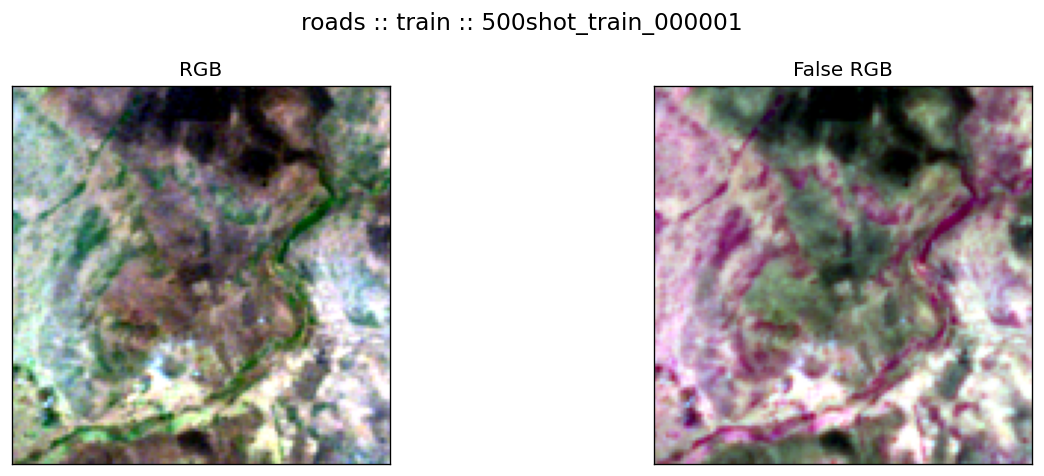

{
  "dataset": "roads",
  "split": "train",
  "sample_id": "500shot_train_000001",
  "image_path": "routerset/images/roads/train/500shot_train_000001_0_0_128_128.npy",
  "shape": [
    128,
    128,
    10
  ],
  "dtype": "uint16",
  "layout": "hwc",
  "min": 444.0,
  "max": 976.0,
  "mean": 626.89501953125,
  "zero_fraction": 0.0,
  "stats_sampled": true,
  "label_names": [
    "road_present"
  ],
  "status": "ok",
  "issue_codes": [],
  "note_codes": [
    "sampled_large_array_stats",
    "raw_uint16_reflectance"
  ]
}


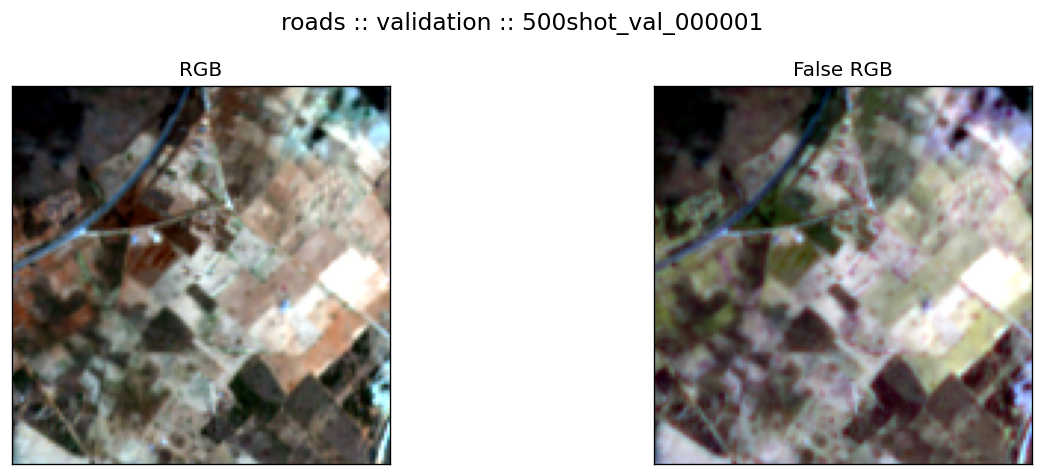

{
  "dataset": "roads",
  "split": "validation",
  "sample_id": "500shot_val_000001",
  "image_path": "routerset/images/roads/validation/500shot_val_000001_0_0_128_128.npy",
  "shape": [
    128,
    128,
    10
  ],
  "dtype": "uint16",
  "layout": "hwc",
  "min": 383.0,
  "max": 1582.0,
  "mean": 773.205322265625,
  "zero_fraction": 0.0,
  "stats_sampled": true,
  "label_names": [
    "road_present"
  ],
  "status": "ok",
  "issue_codes": [],
  "note_codes": [
    "sampled_large_array_stats",
    "raw_uint16_reflectance"
  ]
}


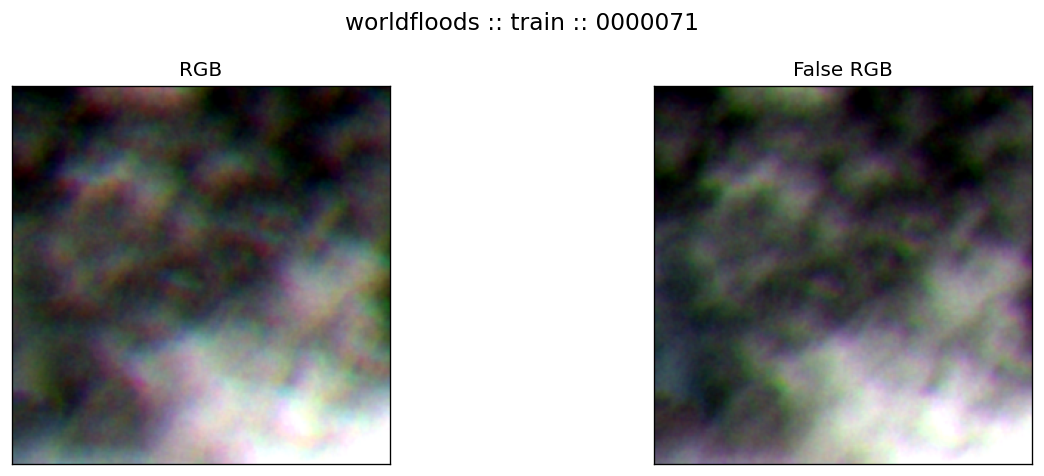

{
  "dataset": "worldfloods",
  "split": "train",
  "sample_id": "0000071",
  "image_path": "routerset/images/worldfloods/train/0000071_0_256_256_256.npy",
  "shape": [
    8,
    256,
    256
  ],
  "dtype": "float32",
  "layout": "chw",
  "min": 0.11089999973773956,
  "max": 0.36660000681877136,
  "mean": 0.20094475150108337,
  "zero_fraction": 0.0,
  "stats_sampled": true,
  "label_names": [
    "cloud",
    "water"
  ],
  "status": "ok",
  "issue_codes": [],
  "note_codes": [
    "sampled_large_array_stats"
  ]
}


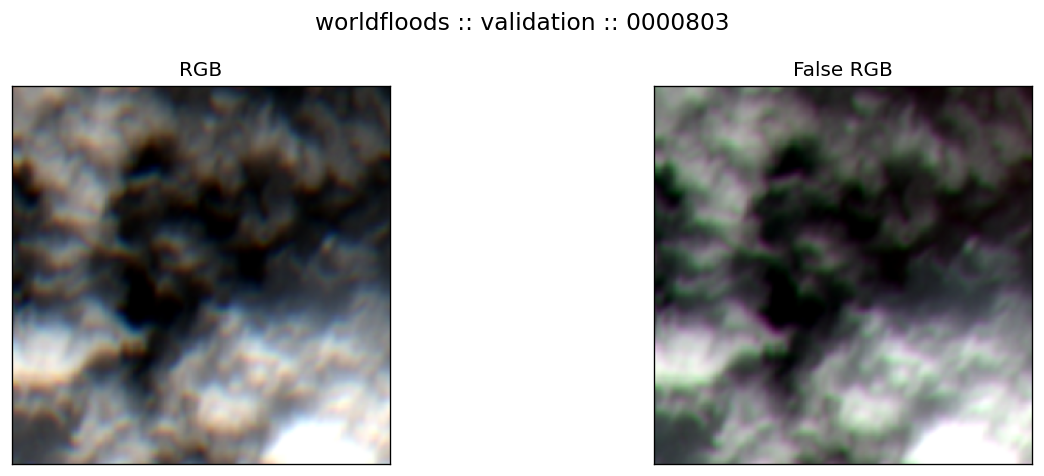

{
  "dataset": "worldfloods",
  "split": "validation",
  "sample_id": "0000803",
  "image_path": "routerset/images/worldfloods/validation/0000803_0_0_256_256.npy",
  "shape": [
    8,
    256,
    256
  ],
  "dtype": "float32",
  "layout": "chw",
  "min": 0.07240000367164612,
  "max": 1.114400029182434,
  "mean": 0.38650524616241455,
  "zero_fraction": 0.0,
  "stats_sampled": true,
  "label_names": [
    "cloud",
    "land",
    "water"
  ],
  "status": "ok",
  "issue_codes": [],
  "note_codes": [
    "sampled_large_array_stats"
  ]
}


In [4]:
display(Markdown('## Sample gallery'))

for row in sample_rows:
    array = np.load(Path(row['image_path']), mmap_mode='r')
    chw = display_view(array)
    rgb = normalize_display(chw, channels=RGB_CHANNELS)
    false_rgb = normalize_display(chw, channels=FALSE_RGB_CHANNELS)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(rgb)
    axes[0].set_title('RGB')
    axes[1].imshow(false_rgb)
    axes[1].set_title('False RGB')
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    title = f"{row['source_dataset']} :: {row['source_split']} :: {row['source_sample_id']}"
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

    payload = {
        'dataset': row['source_dataset'],
        'split': row['source_split'],
        'sample_id': row['source_sample_id'],
        'image_path': row['image_path'],
        'shape': row.get('shape'),
        'dtype': row.get('dtype'),
        'layout': row.get('layout'),
        'min': row.get('min'),
        'max': row.get('max'),
        'mean': row.get('mean'),
        'zero_fraction': row.get('zero_fraction'),
        'stats_sampled': row.get('stats_sampled'),
        'label_names': row.get('label_names', []),
        'status': row.get('status'),
        'issue_codes': row.get('issue_codes', []),
        'note_codes': row.get('note_codes', []),
    }
    print(json.dumps(payload, indent=2))
